### Deep Agents

Build agents that can plan, use subagents, and leverage file systems for complex tasks

deepagents is a standalone library for building agents that can tackle complex, multi-step tasks. Built on LangGraph and inspired by applications like Claude Code, Deep Research, and Manus, deep agents come with planning capabilities, file systems for context management, and the ability to spawn subagents.

##### When to use deep agents?

Use deep agents when you need agents that can:
- Handle complex, multi-step tasks that require planning and decomposition
- Manage large amounts of context through file system tools
- Delegate work to specialized subagents for context isolation
- Persist memory across conversations and threads

In [1]:
# Basic deep agent

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [2]:
# Tools - Internet search

from tavily import TavilyClient
from typing import Literal

tavily_client = TavilyClient(api_key = os.getenv("TAVILY_API_KEY"))

def web_search(query: str, max_results: int = 5, 
               topic: Literal["general", "sports", "news", "finance"] = "general", 
               include_raw_content: bool = False):
    """Run a web search"""
    return tavily_client.search(query,
                                max_results = max_results, 
                                include_raw_content = include_raw_content, 
                                topic = topic
                                )

In [7]:
from langchain.chat_models import init_chat_model

model = init_chat_model("groq:openai/gpt-oss-120b", temperature = 0.2)

model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000284CCDDE490>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000284CCDDEE90>, model_name='openai/gpt-oss-120b', temperature=0.2, model_kwargs={}, groq_api_key=SecretStr('**********'))

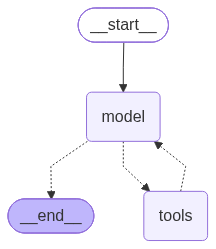

In [8]:
# Basic Agent

from langchain.agents import create_agent

simple_agent = create_agent(
    model = model,
    tools = [web_search]
)

simple_agent

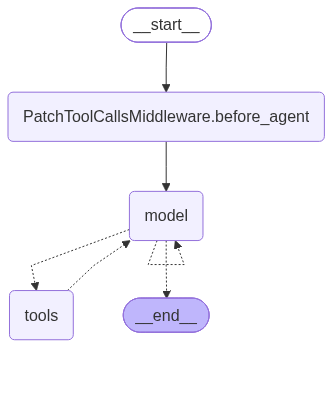

In [9]:
# Creating a Deep Agent
# Prompt

# Agent
from deepagents import create_deep_agent

deepagent = create_deep_agent(
    model = model,
    tools = [web_search],
    system_prompt = "Act as a researcher"
)

deepagent

In [10]:
result = deepagent.invoke({"messages": [{"role": "user", "content": "What are Deep Agents?"}]})

result

{'messages': [HumanMessage(content='What are Deep Agents?', additional_kwargs={}, response_metadata={}, id='315e38f2-51af-4846-9aa4-83b98162f88a'),
  AIMessage(content='**Deep Agents** is a term that’s used in a few related but distinct contexts within artificial intelligence and machine learning. At its core, a *deep agent* is an autonomous decision‑making system that leverages **deep learning** (i.e., neural networks with many layers) to perceive its environment, reason about it, and select actions. Below is a concise overview of the most common meanings and the key ideas that tie them together.\n\n---\n\n## 1. Deep Reinforcement‑Learning (RL) Agents  \n\n### What they are  \n- **Reinforcement learning** frames an agent’s interaction with an environment as a sequential decision‑making problem: the agent observes a state, takes an action, receives a reward, and updates its policy to maximize cumulative reward.  \n- **Deep RL** replaces the traditional tabular or linear function approx

In [11]:
result["messages"][-1].content

'**Deep Agents** is a term that’s used in a few related but distinct contexts within artificial intelligence and machine learning. At its core, a *deep agent* is an autonomous decision‑making system that leverages **deep learning** (i.e., neural networks with many layers) to perceive its environment, reason about it, and select actions. Below is a concise overview of the most common meanings and the key ideas that tie them together.\n\n---\n\n## 1. Deep Reinforcement‑Learning (RL) Agents  \n\n### What they are  \n- **Reinforcement learning** frames an agent’s interaction with an environment as a sequential decision‑making problem: the agent observes a state, takes an action, receives a reward, and updates its policy to maximize cumulative reward.  \n- **Deep RL** replaces the traditional tabular or linear function approximators with **deep neural networks** (e.g., convolutional nets, recurrent nets, transformers). These networks can handle high‑dimensional inputs such as raw pixels, au

In [13]:
result['files']

{}

##### What happened?
Your deep agent automatically:
1. Planned its approach: Used the built-in write_todos tool to break down the research task
2. Conducted research: Called the internet_search tool to gather information
3. Managed context: Used file system tools (write_file, read_file) to offload large search results
4. Spaned subagents (if needed): Delegated complex subtasks to specialized subagents
5. Synthesized a report: Compiled findings into a coherent response

#### Customizing Deep Agents

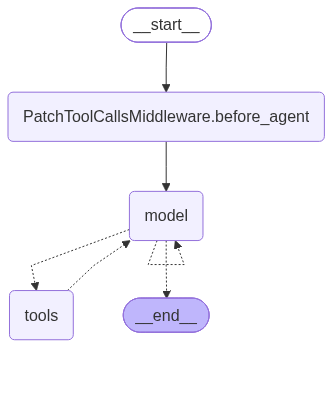

In [15]:
# Model

from langchain.chat_models import init_chat_model
from deepagents import create_deep_agent

model = init_chat_model(model = "groq:openai/gpt-oss-120b")
agent = create_deep_agent(model = model)

agent

In [16]:
result = agent.invoke({"messages": [{"role": "user", "content": "What are Deep Agents?"}]})

result

{'messages': [HumanMessage(content='What are Deep Agents?', additional_kwargs={}, response_metadata={}, id='95f27cb8-5a6b-4b59-8863-40092b6f442c'),
  AIMessage(content='**Deep Agents** are a class of AI systems that combine the strengths of large language models (LLMs) with deeper, more structured reasoning, planning, and interaction capabilities. While a standard LLM can generate fluent text and answer many questions directly, a Deep Agent adds several layers of “depth” that let it:\n\n| Layer | What it adds | Why it matters |\n|-------|--------------|----------------|\n| **Goal‑oriented planning** | The ability to break a high‑level objective into sub‑tasks, create a plan, and track progress. | Turns vague prompts (“write a business plan”) into concrete, step‑by‑step workflows. |\n| **Tool use & API integration** | Dynamically calls external tools (search, code execution, file I/O, databases, web APIs, etc.) to fetch up‑to‑date information or perform actions. | Gives the agent access

#### System Prompt
Deep agents come with a built-in system prompt inspired by Claude Code’s system prompt. The default system prompt contains detailed instructions for using the built-in planning tool, file system tools, and subagents. Each deep agent tailored to a use case should include a custom system prompt specific to that use case.

In [17]:
from deepagents import create_deep_agent

research_instructions = """\
You are an expert researcher. Your job is to conduct \
thorough research, and then write a polished report. \
"""

agent = create_deep_agent(
    model = model,
    system_prompt = research_instructions,
)
result = agent.invoke({"messages": [{"role": "user", "content": "What are Deep Agents?"}]})
result

{'messages': [HumanMessage(content='What are Deep Agents?', additional_kwargs={}, response_metadata={}, id='19d3aac3-6f70-4314-aea3-7113293030bf'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer: "What are Deep Agents?" As an expert researcher, we need to conduct thorough research and write a polished report. Likely need to browse the filesystem for relevant docs. Let\'s search.', 'tool_calls': [{'id': 'fc_429ad2a1-a56e-4e26-acf7-4f0fd8c2352c', 'function': {'arguments': '{"path":"","pattern":"*deep*agent*"}', 'name': 'glob'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 1959, 'total_tokens': 2034, 'completion_time': 0.157979161, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.197111882, 'prompt_tokens_details': None, 'queue_time': 0.359338183, 'total_time': 0.355091043}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8ea50c0161', 'service_tier': 'on_demand'

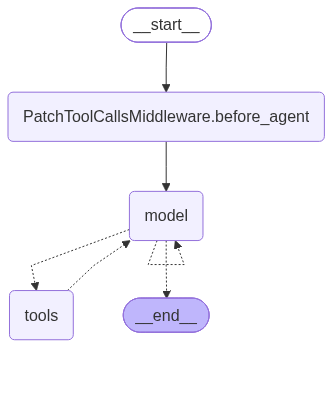

In [18]:
agent

In [20]:
# Tools

import os
from typing import Literal
from tavily import TavilyClient
from deepagents import create_deep_agent

tavily_client = TavilyClient(api_key = os.environ["TAVILY_API_KEY"])

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,
):
    """Run a web search"""
    return tavily_client.search(
        query,
        max_results = max_results,
        include_raw_content = include_raw_content,
        topic = topic,
    )

agent = create_deep_agent(
    model = model,
    tools = [internet_search]
)
result = agent.invoke({"messages": [{"role": "user", "content": "What are Deep Agents, and what is theit role in Agentic AI?"}]})

result

{'messages': [HumanMessage(content='What are Deep Agents, and what is theit role in Agentic AI?', additional_kwargs={}, response_metadata={}, id='3d2f2fd0-6781-4c38-b2a9-aa332ec5dd97'),
  AIMessage(content='**Deep Agents – a quick overview**\n\nA **Deep Agent** is a type of autonomous AI system that combines the strengths of large‑language models (LLMs) with deeper, often multi‑modal reasoning and planning capabilities. While a “plain” LLM‑based agent can follow a prompt, generate text, and call simple tools, a Deep Agent goes a step further:\n\n| Aspect | Regular LLM‑based Agent | Deep Agent |\n|--------|--------------------------|------------|\n| **Core model** | One or a few LLM calls (GPT‑4, Claude, Llama, etc.) | One or more LLMs **plus** additional neural modules (e.g., vision encoders, graph neural networks, reinforcement‑learning‑based planners) |\n| **Memory & state** | Short‑term (session) memory, sometimes a vector store | Persistent, hierarchical memory (episodic + semantic